# Report
## Highlights
- Prediction error was around 0.51 t/ha for the ML algorithm using monthly data, the lowest prediction error was aroung 0.38 t/ha in 2019. 

- Most predictions were relatively close to APSIM yield: on average, about 61% (75% is the highest) of ML predictions were within ±0.5 t/ha of the APSIM yield, and about 13% were more than 1.0-1.3 t/ha away.

- LCCC mostly around 0.74 to 0.82. Performace of the ML algorithm varies across the year. In 2019, LCCC is approximately 0.82 and R2 about 0.69,


## Data
### Sowing rule

- Northern locations (Qld and Nth. NSW) if grid point latitude > -32.24 and longitude > 140.99
Sow if rain >=15mm over 3 days and PAW>=30mm from 26 April-31 July

- Southern locations (SA, Sth. NSW, Vic, Tas) if grid point latitude < -32.25 and longitude > 129
Sow if rain >=15mm over 3 days regardless of soil moisture from 26 April-31 July

- Western locations (WA) if grid point longitude <= 129
Sow if rain >=15mm over 3 days regardless of soil moisture from 1 April-31 July
For all locations, if a wheat crop was not established by the end of the sowing window, a
crop was sown on the last day, i.e., 31 July.

- All wheat crops were sown with:
Sowing density = 150 plants/m2, row spacing =250mm, sowing depth = 70mm

### Climate variables
- `rain_crop`  :total rainfall during the crop season. 

- `rad_sum_crop` :total solar radiation during the crop season.

- `VPD_mean_crop` : average vapour pressure deficit during the season (equation 88)

- `TT_cum_crop` : Cumulative thermal time by computing crown temperature

- `FASW_mean_crop` :mean fraction of available soil water during the season (fraction of PAW/PAWC)

### Stage-specific variables
- **W2** = vegetative stage
- **W3** = preanthesis
- **W4** = grain filling

- `Tmean_W2_veg`: average temperature during the vegetative stage

- `rad_sum_W3_preanth`: radiation received before flowering

- `rain_W4_grainFill`: rainfall during grain filling

- `fw_photo_mean_W2_veg`: water stress factor affecting photosynthesis during the vegetative stage.

- `fT_photo_mean_W3_preanth`: temperature response factor for photosynthesis before flowering.

- `heat_days_W4_grainFill`: number of hot days during grain filling. 

- `frost_days_W3_preAnth`: number of frost days before flowering. 
### Soil variables

- `pawc_0_30_mm`
- `pawc_0_60_mm`
- `minN_0_30`
- `minN_30_60`
- `ph_0_30`
- `ph_30_60`
- `profile_depth_cm`

### Spatial features

- Using raw `lat` and `lon`
- Also consider **spatial clusters**

How this works:

- Each grid cell is described using:
   - soil properties
   - long-term climate normals

- K-means clustering groups similar cells into about **25 agro-ecological zones**.

- These zones are then used as model inputs, for example:

- `cluster_0`
- `cluster_1`
- ...
- `cluster_24`

The clusters give the model an **environment type** rather than a simple location coordinate.


## Monthly ML

The monthly ML features are created from climate, water, and soil variables for each grid cell and year.



### Monthly variable families

For each time window, the following variables are calculated:

- **Rain**
  - `rain_sum`
  - `rain_days`

- **Radiation**
  - `rad_mean`
  - `rad_sum`

- **Temperature**
  - `tmean`
  - `tmax_max`
  - `tmin_min`
  - `diurnal`

- **Thermal time**
  - `tt_sum`

- **Temperature stress**
  - `fT_photo`

- **Heat stress**
  - `heat_days`

- **Frost stress**
  - `frost_days`

- **VPD**
  - `vpd_mean`

- **Water status**
  - `fasw_mean`
  - `fw_photo`

### Time windows used in the model

The model stores these variables for three different time structures:

####  Pre-sowing monthly features
These represent the **3 months before sowing**:

- `*_pre3`
- `*_pre2`
- `*_pre1`

Examples:
- `rain_sum_pre3`
- `vpd_mean_pre1`
- `tt_sum_pre2`

#### Post-sowing monthly features
These represent the sowing month and the following 8 months:

- `*_m0` = sowing month
- `*_m1`
- `*_m2`
- ...
- `*_m8`

Examples:
- `rain_sum_m0`
- `tmean_m3`
- `fasw_mean_m5`

#### Whole crop-cycle features
These aggregate values across the **entire crop period from sowing onward**:

- `rain_sum_crop`
- `tt_sum_crop`
- `vpd_mean_crop`
- `fasw_mean_crop`
#### Soil variables

- `pawc_0_30_mm`
- `pawc_0_60_mm`
- `minN_0_30`
- `minN_30_60`
- `ph_0_30`
- `ph_30_60`
- `profile_depth_cm`


## Results

In [27]:
import pandas as pd
from pathlib import Path
from IPython.display import Image, display

In [42]:

file_path = Path("../outputs/ml_results_v9/per_year_per_fold_metrics.csv")

df = pd.read_csv(file_path)
print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

report_df = df[[
    "LCCC",
    "Bias_tha",
    "MAE_tha",
    "RMSE_tha",
    "R2",
    "train_years",
    "test_year"
]].copy()

report_df = report_df.rename(columns={
    "Bias_tha": "Bias",
    "MAE_tha": "MAE",
    "RMSE_tha": "RMSE"   
})
report_df = report_df.sort_values(
    by=["test_year", "train_years"],
    ascending=[True, True]
).reset_index(drop=True)

for test_year, group in report_df.groupby("test_year", sort=True):
    print(f"\n========== test_year: {test_year} ==========")
    display(group.sort_values("train_years").reset_index(drop=True))

Shape: (15, 12)
Columns:
['n', 'R2', 'RMSE_tha', 'MAE_tha', 'Bias_tha', 'NSE', 'NRMSE_pct', 'LCCC', 'fold', 'train_years', 'test_year', 'train_size']

========== test_year: 2017 ==========


,LCCC,Bias,MAE,RMSE,R2,train_years,test_year
0,0.705857,-0.101124,0.587211,0.772912,0.534579,1989-2016,2017



========== test_year: 2018 ==========


,LCCC,Bias,MAE,RMSE,R2,train_years,test_year
0,0.601749,0.159201,0.578368,0.802301,0.317630,1989-2016,2018
1,0.598795,0.193026,0.584221,0.807767,0.308301,1989-2017,2018



========== test_year: 2019 ==========


,LCCC,Bias,MAE,RMSE,R2,train_years,test_year
0,0.711841,0.247543,0.484357,0.651601,0.491220,1989-2016,2019
1,0.708176,0.254639,0.489427,0.658223,0.480827,1989-2017,2019
2,0.719745,0.239561,0.480124,0.641947,0.506184,1989-2018,2019



========== test_year: 2020 ==========


,LCCC,Bias,MAE,RMSE,R2,train_years,test_year
0,0.714232,-0.162184,0.667319,0.898761,0.570528,1989-2016,2020
1,0.726202,-0.126016,0.655037,0.885115,0.583470,1989-2017,2020
2,0.736075,-0.128297,0.637872,0.869100,0.598407,1989-2018,2020
3,0.731350,-0.158212,0.643525,0.878299,0.589861,1989-2019,2020



========== test_year: 2021 ==========


,LCCC,Bias,MAE,RMSE,R2,train_years,test_year
0,0.823373,-0.001505,0.517541,0.665736,0.702635,1989-2016,2021
1,0.826696,-0.004101,0.511107,0.657298,0.710124,1989-2017,2021
2,0.819958,0.006633,0.526577,0.674929,0.694365,1989-2018,2021
3,0.818544,-0.011249,0.525901,0.673655,0.695518,1989-2019,2021
4,0.816934,-0.005560,0.529724,0.678870,0.690786,1989-2020,2021


In [41]:

file_path = Path("../outputs/ml_monthly_results/per_year_per_fold_metrics.csv")

df = pd.read_csv(file_path)
print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

report_df = df[[
    "LCCC",
    "Bias_tha",
    "MAE_tha",
    "RMSE_tha",
    "R2",
    "train_years",
    "test_year"
]].copy()

report_df = report_df.rename(columns={
    "Bias_tha": "Bias",
    "MAE_tha": "MAE",
    "RMSE_tha": "RMSE"   
})
report_df = report_df.sort_values(
    by=["test_year", "train_years"],
    ascending=[True, True]
).reset_index(drop=True)

for test_year, group in report_df.groupby("test_year", sort=True):
    print(f"\n========== test_year: {test_year} ==========")
    display(group.sort_values("train_years").reset_index(drop=True))

Shape: (15, 12)
Columns:
['n', 'R2', 'RMSE_tha', 'MAE_tha', 'Bias_tha', 'NSE', 'NRMSE_pct', 'LCCC', 'fold', 'train_years', 'test_year', 'train_size']

========== test_year: 2017 ==========


,LCCC,Bias,MAE,RMSE,R2,train_years,test_year
0,0.749865,-0.193613,0.536351,0.724995,0.590498,1989-2016,2017



========== test_year: 2018 ==========


,LCCC,Bias,MAE,RMSE,R2,train_years,test_year
0,0.742385,0.007272,0.461318,0.623861,0.587408,1989-2016,2018
1,0.757011,0.034064,0.448857,0.603640,0.613721,1989-2017,2018



========== test_year: 2019 ==========


,LCCC,Bias,MAE,RMSE,R2,train_years,test_year
0,0.808669,-0.000633,0.383899,0.530640,0.662583,1989-2016,2019
1,0.817156,0.009498,0.371745,0.519550,0.676539,1989-2017,2019
2,0.823574,-0.024133,0.368173,0.507582,0.691270,1989-2018,2019



========== test_year: 2020 ==========


,LCCC,Bias,MAE,RMSE,R2,train_years,test_year
0,0.813500,-0.113329,0.546119,0.742912,0.706559,1989-2016,2020
1,0.811561,-0.050637,0.542635,0.741288,0.707840,1989-2017,2020
2,0.816866,-0.057398,0.535450,0.731897,0.715196,1989-2018,2020
3,0.815018,-0.049890,0.534683,0.736497,0.711605,1989-2019,2020



========== test_year: 2021 ==========


,LCCC,Bias,MAE,RMSE,R2,train_years,test_year
0,0.762344,-0.221279,0.593696,0.758984,0.613498,1989-2016,2021
1,0.751448,-0.222467,0.599065,0.773730,0.598333,1989-2017,2021
2,0.760082,-0.221143,0.583453,0.755503,0.617035,1989-2018,2021
3,0.769799,-0.218208,0.578908,0.745927,0.626682,1989-2019,2021
4,0.756492,-0.219865,0.584590,0.758191,0.614305,1989-2020,2021


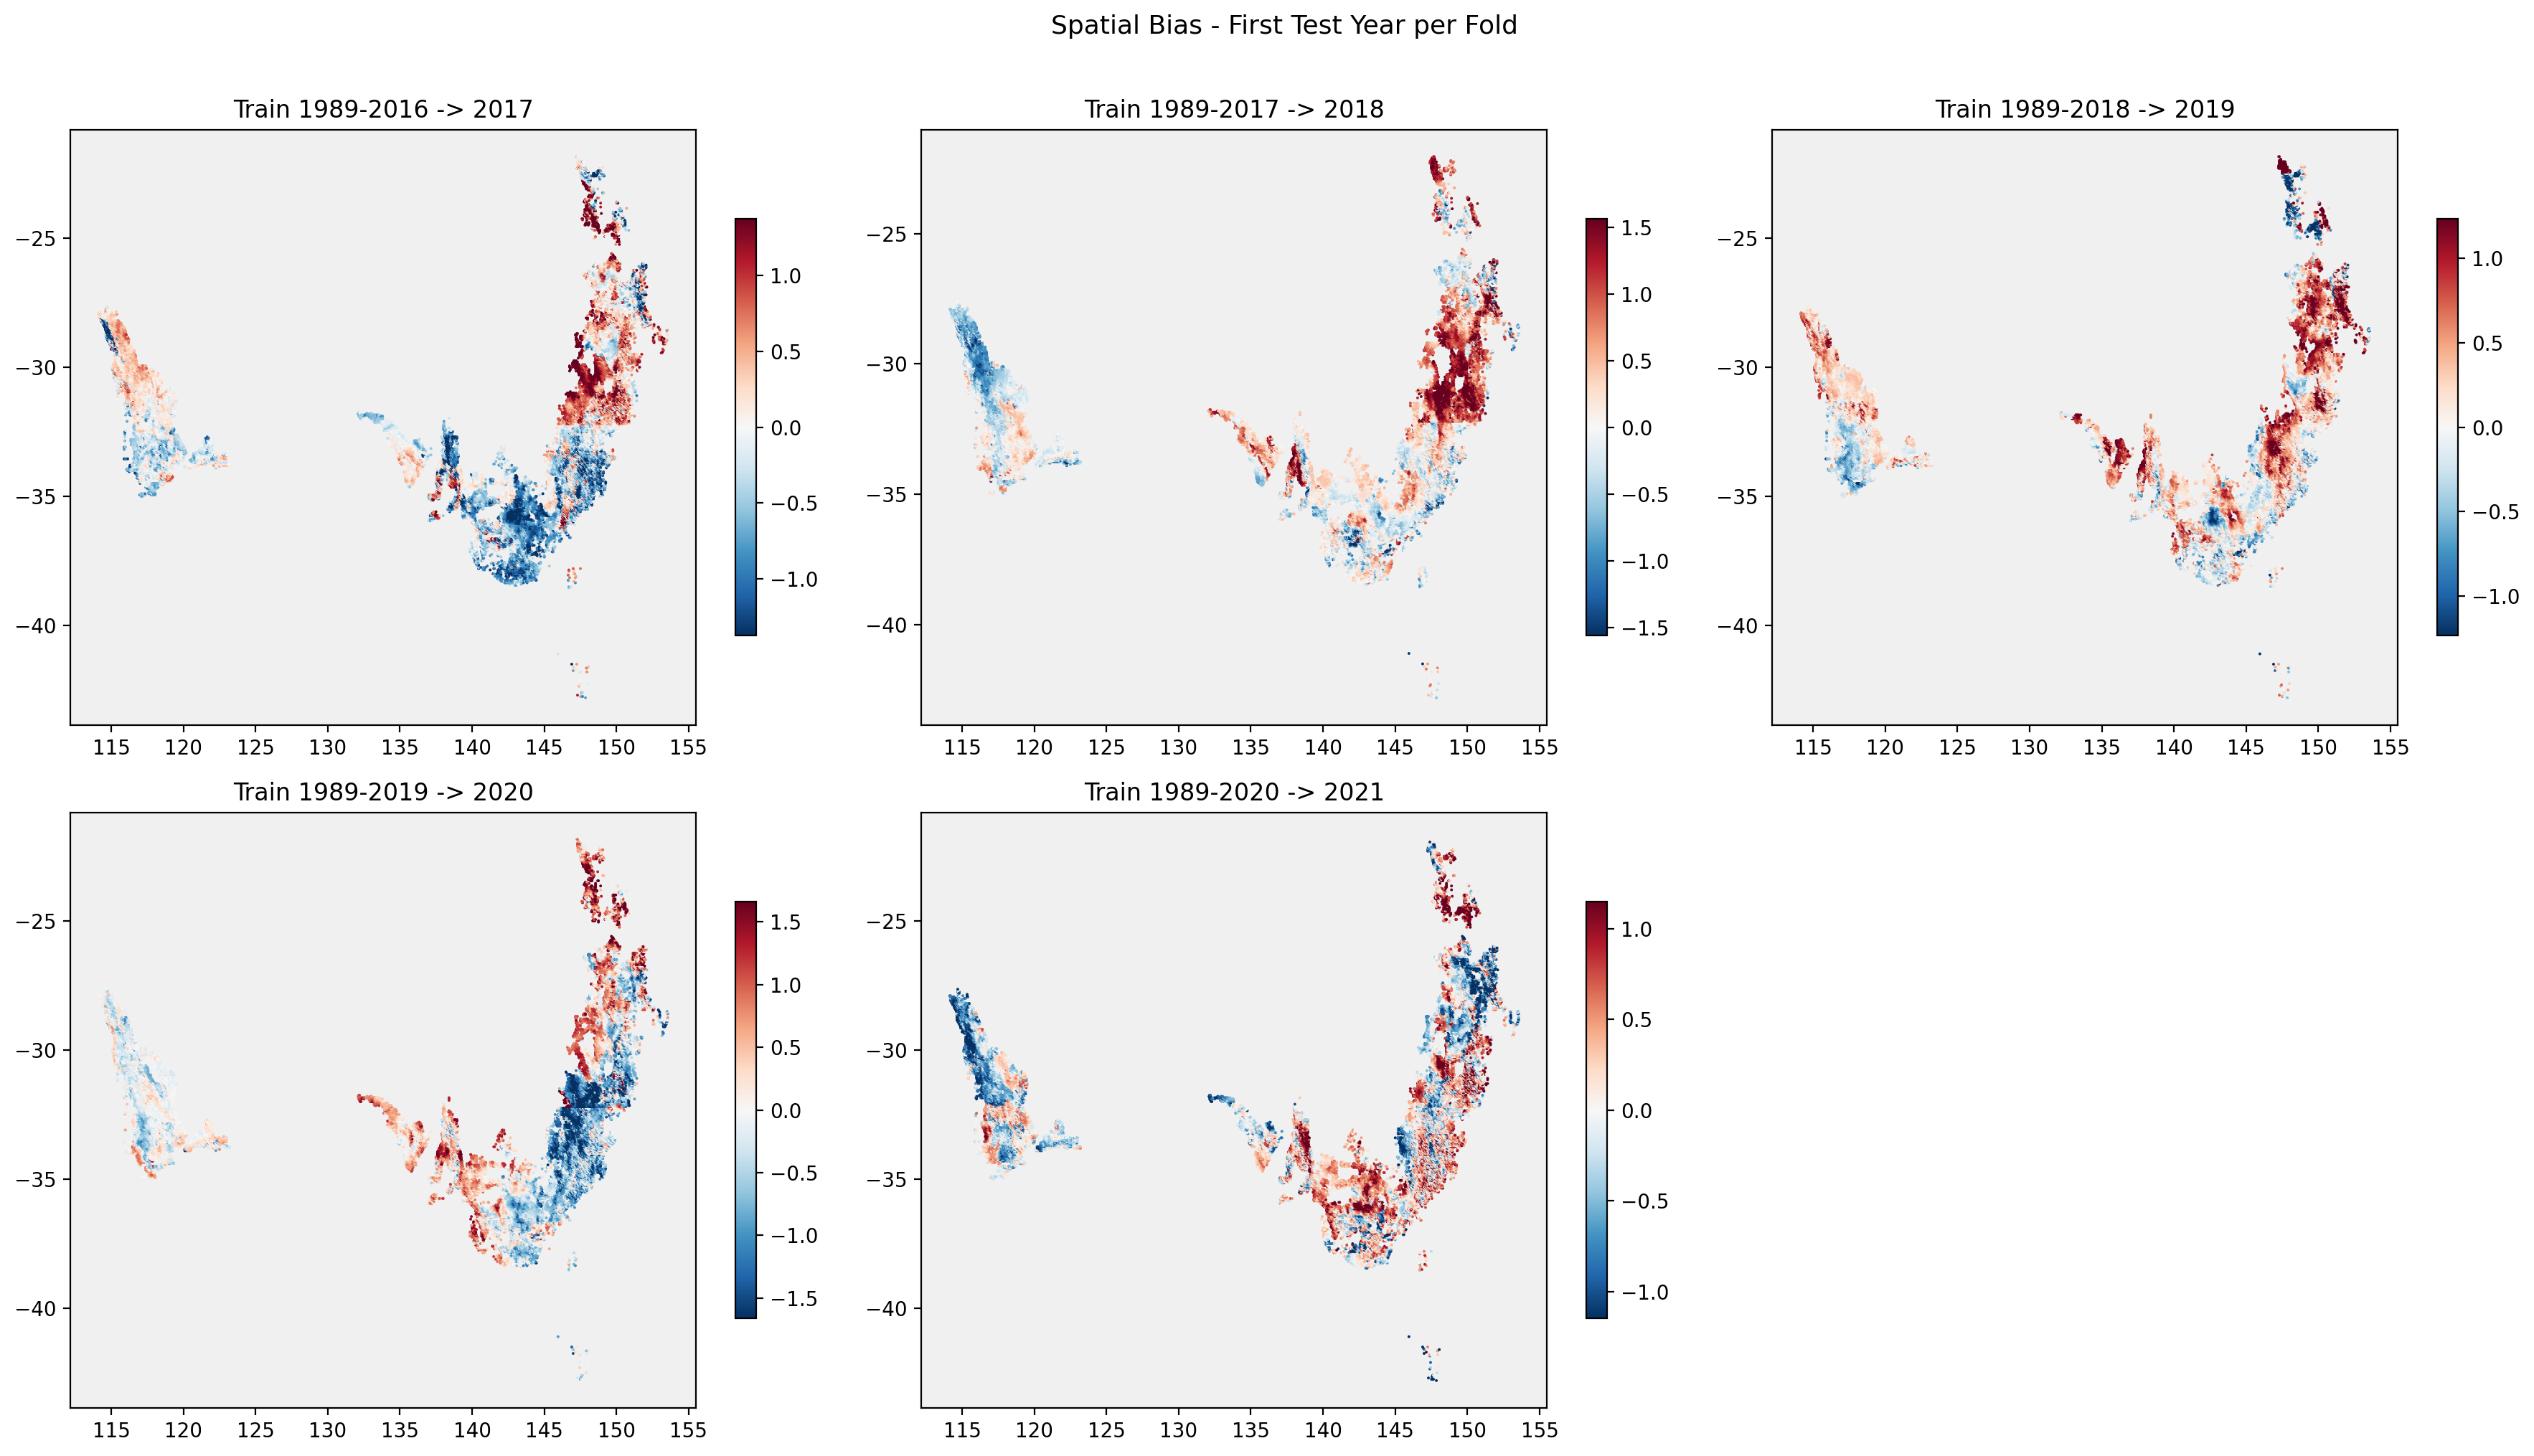

In [30]:
fig_path = Path("../outputs/ml_results_v9/figures/spatial_bias_first_test_year.png")
display(Image(filename=str(fig_path)))

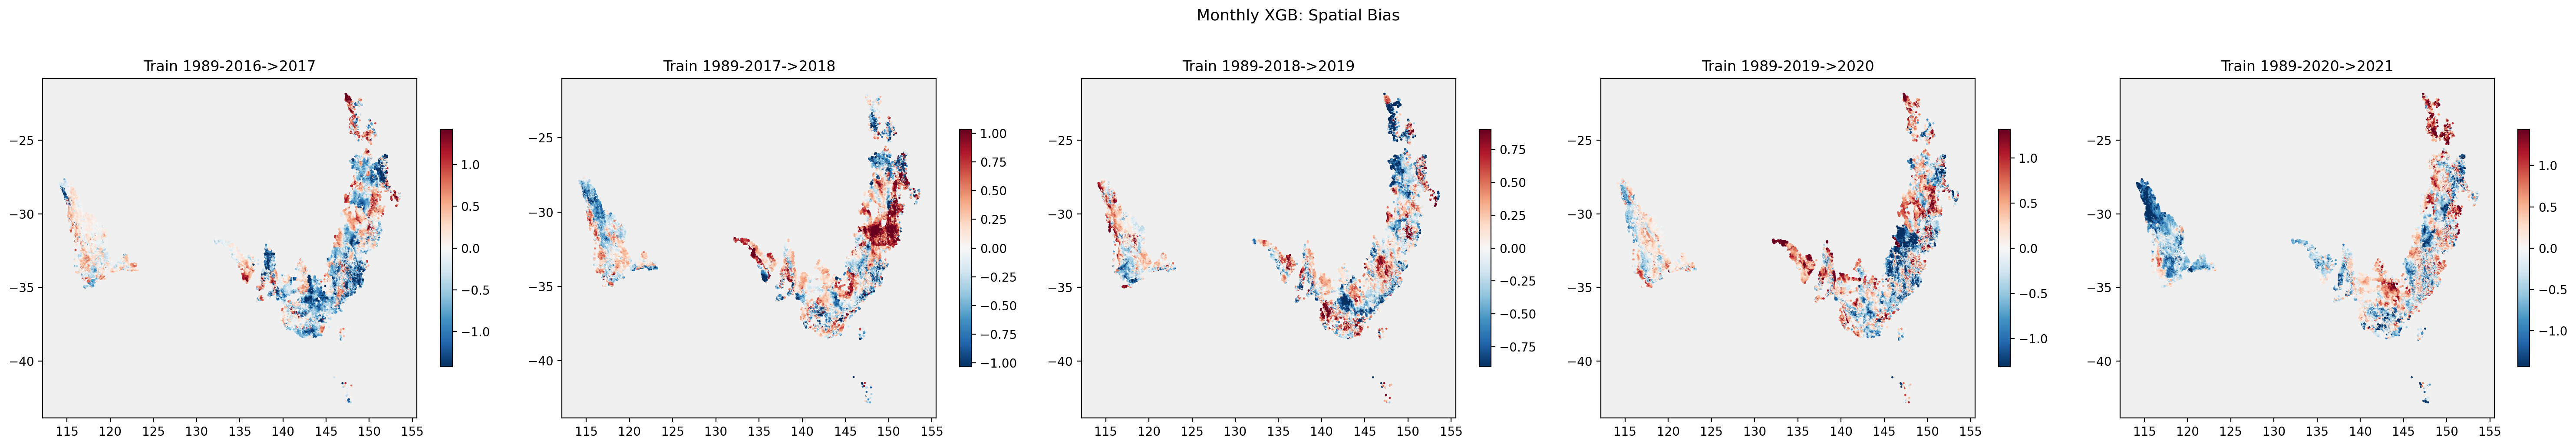

In [31]:
fig_path = Path("../outputs/ml_monthly_results/figures/spatial_bias.png")
display(Image(filename=str(fig_path)))

In [32]:
import numpy as np

df = pd.read_csv("../outputs/ml_results_v9/spatial_bias_per_gridcell.csv")

df["bias_tha"] = pd.to_numeric(df["bias_tha"], errors="coerce")

conditions = [
    df["bias_tha"].between(-0.5, 0.5, inclusive="both"),
    (df["bias_tha"].abs() > 0.5) & (df["bias_tha"].abs() <= 1.0),
    (df["bias_tha"].abs() > 1.0),
]

choices = [
    "pct_bias_between_-0.5_and_0.5",
    "pct_abs_bias_between_0.5_and_1",
    "pct_abs_bias_gt_1",
]

df["bias_bin"] = np.select(conditions, choices, default="other")

df = df[df["bias_bin"] != "other"].copy()

summary = (
    df.groupby(["fold", "year", "bias_bin"])
      .size()
      .unstack(fill_value=0)
)


wanted_cols = [
    "pct_bias_between_-0.5_and_0.5",
    "pct_abs_bias_between_0.5_and_1",
    "pct_abs_bias_gt_1",
]
for c in wanted_cols:
    if c not in summary.columns:
        summary[c] = 0

summary = summary[wanted_cols]

summary_pct = summary.div(summary.sum(axis=1), axis=0) * 100
summary_pct = summary_pct.reset_index().rename(columns={"year": "test_year"})
summary_pct = summary_pct.sort_values(["test_year", "fold"]).reset_index(drop=True)

for c in wanted_cols:
    summary_pct[c] = summary_pct[c].round(2).map(lambda x: f"{x:.2f}%")

summary_pct

bias_bin,fold,test_year,pct_bias_between_-0.5_and_0.5,pct_abs_bias_between_0.5_and_1,pct_abs_bias_gt_1
0,train_1989-2016_test_2017-2021,2017,53.50%,28.05%,18.45%
1,train_1989-2016_test_2017-2021,2018,57.16%,25.24%,17.60%
2,train_1989-2017_test_2018-2021,2018,57.18%,24.45%,18.37%
3,train_1989-2016_test_2017-2021,2019,63.47%,24.82%,11.71%
4,train_1989-2017_test_2018-2021,2019,62.51%,25.74%,11.75%
5,train_1989-2018_test_2019-2021,2019,63.46%,25.40%,11.14%
6,train_1989-2016_test_2017-2021,2020,49.12%,27.92%,22.96%
7,train_1989-2017_test_2018-2021,2020,49.88%,28.36%,21.76%
8,train_1989-2018_test_2019-2021,2020,51.11%,27.76%,21.14%
9,train_1989-2019_test_2020-2021,2020,50.79%,28.21%,21.00%


In [33]:
df = pd.read_csv("../outputs/ml_monthly_results/spatial_bias_per_gridcell.csv")

df["bias_tha"] = pd.to_numeric(df["bias_tha"], errors="coerce")

conditions = [
    df["bias_tha"].between(-0.5, 0.5, inclusive="both"),
    (df["bias_tha"].abs() > 0.5) & (df["bias_tha"].abs() <= 1.0),
    (df["bias_tha"].abs() > 1.0),
]

choices = [
    "pct_bias_between_-0.5_and_0.5",
    "pct_abs_bias_between_0.5_and_1",
    "pct_abs_bias_gt_1",
]

df["bias_bin"] = np.select(conditions, choices, default="other")

df = df[df["bias_bin"] != "other"].copy()

summary = (
    df.groupby(["fold", "year", "bias_bin"])
      .size()
      .unstack(fill_value=0)
)

wanted_cols = [
    "pct_bias_between_-0.5_and_0.5",
    "pct_abs_bias_between_0.5_and_1",
    "pct_abs_bias_gt_1",
]
for c in wanted_cols:
    if c not in summary.columns:
        summary[c] = 0

summary = summary[wanted_cols]

summary_pct = summary.div(summary.sum(axis=1), axis=0) * 100
summary_pct = summary_pct.reset_index().rename(columns={"year": "test_year"})
summary_pct = summary_pct.sort_values(["test_year", "fold"]).reset_index(drop=True)

for c in wanted_cols:
    summary_pct[c] = summary_pct[c].round(2).map(lambda x: f"{x:.2f}%")

summary_pct

bias_bin,fold,test_year,pct_bias_between_-0.5_and_0.5,pct_abs_bias_between_0.5_and_1,pct_abs_bias_gt_1
0,train_1989-2016_test_2017-2021,2017,57.78%,27.22%,15.00%
1,train_1989-2016_test_2017-2021,2018,65.22%,24.71%,10.07%
2,train_1989-2017_test_2018-2021,2018,66.54%,24.20%,9.26%
3,train_1989-2016_test_2017-2021,2019,73.33%,20.35%,6.32%
4,train_1989-2017_test_2018-2021,2019,74.85%,18.80%,6.35%
5,train_1989-2018_test_2019-2021,2019,75.00%,19.04%,5.96%
6,train_1989-2016_test_2017-2021,2020,58.46%,26.62%,14.92%
7,train_1989-2017_test_2018-2021,2020,58.37%,27.19%,14.44%
8,train_1989-2018_test_2019-2021,2020,59.26%,26.69%,14.05%
9,train_1989-2019_test_2020-2021,2020,59.33%,26.23%,14.44%


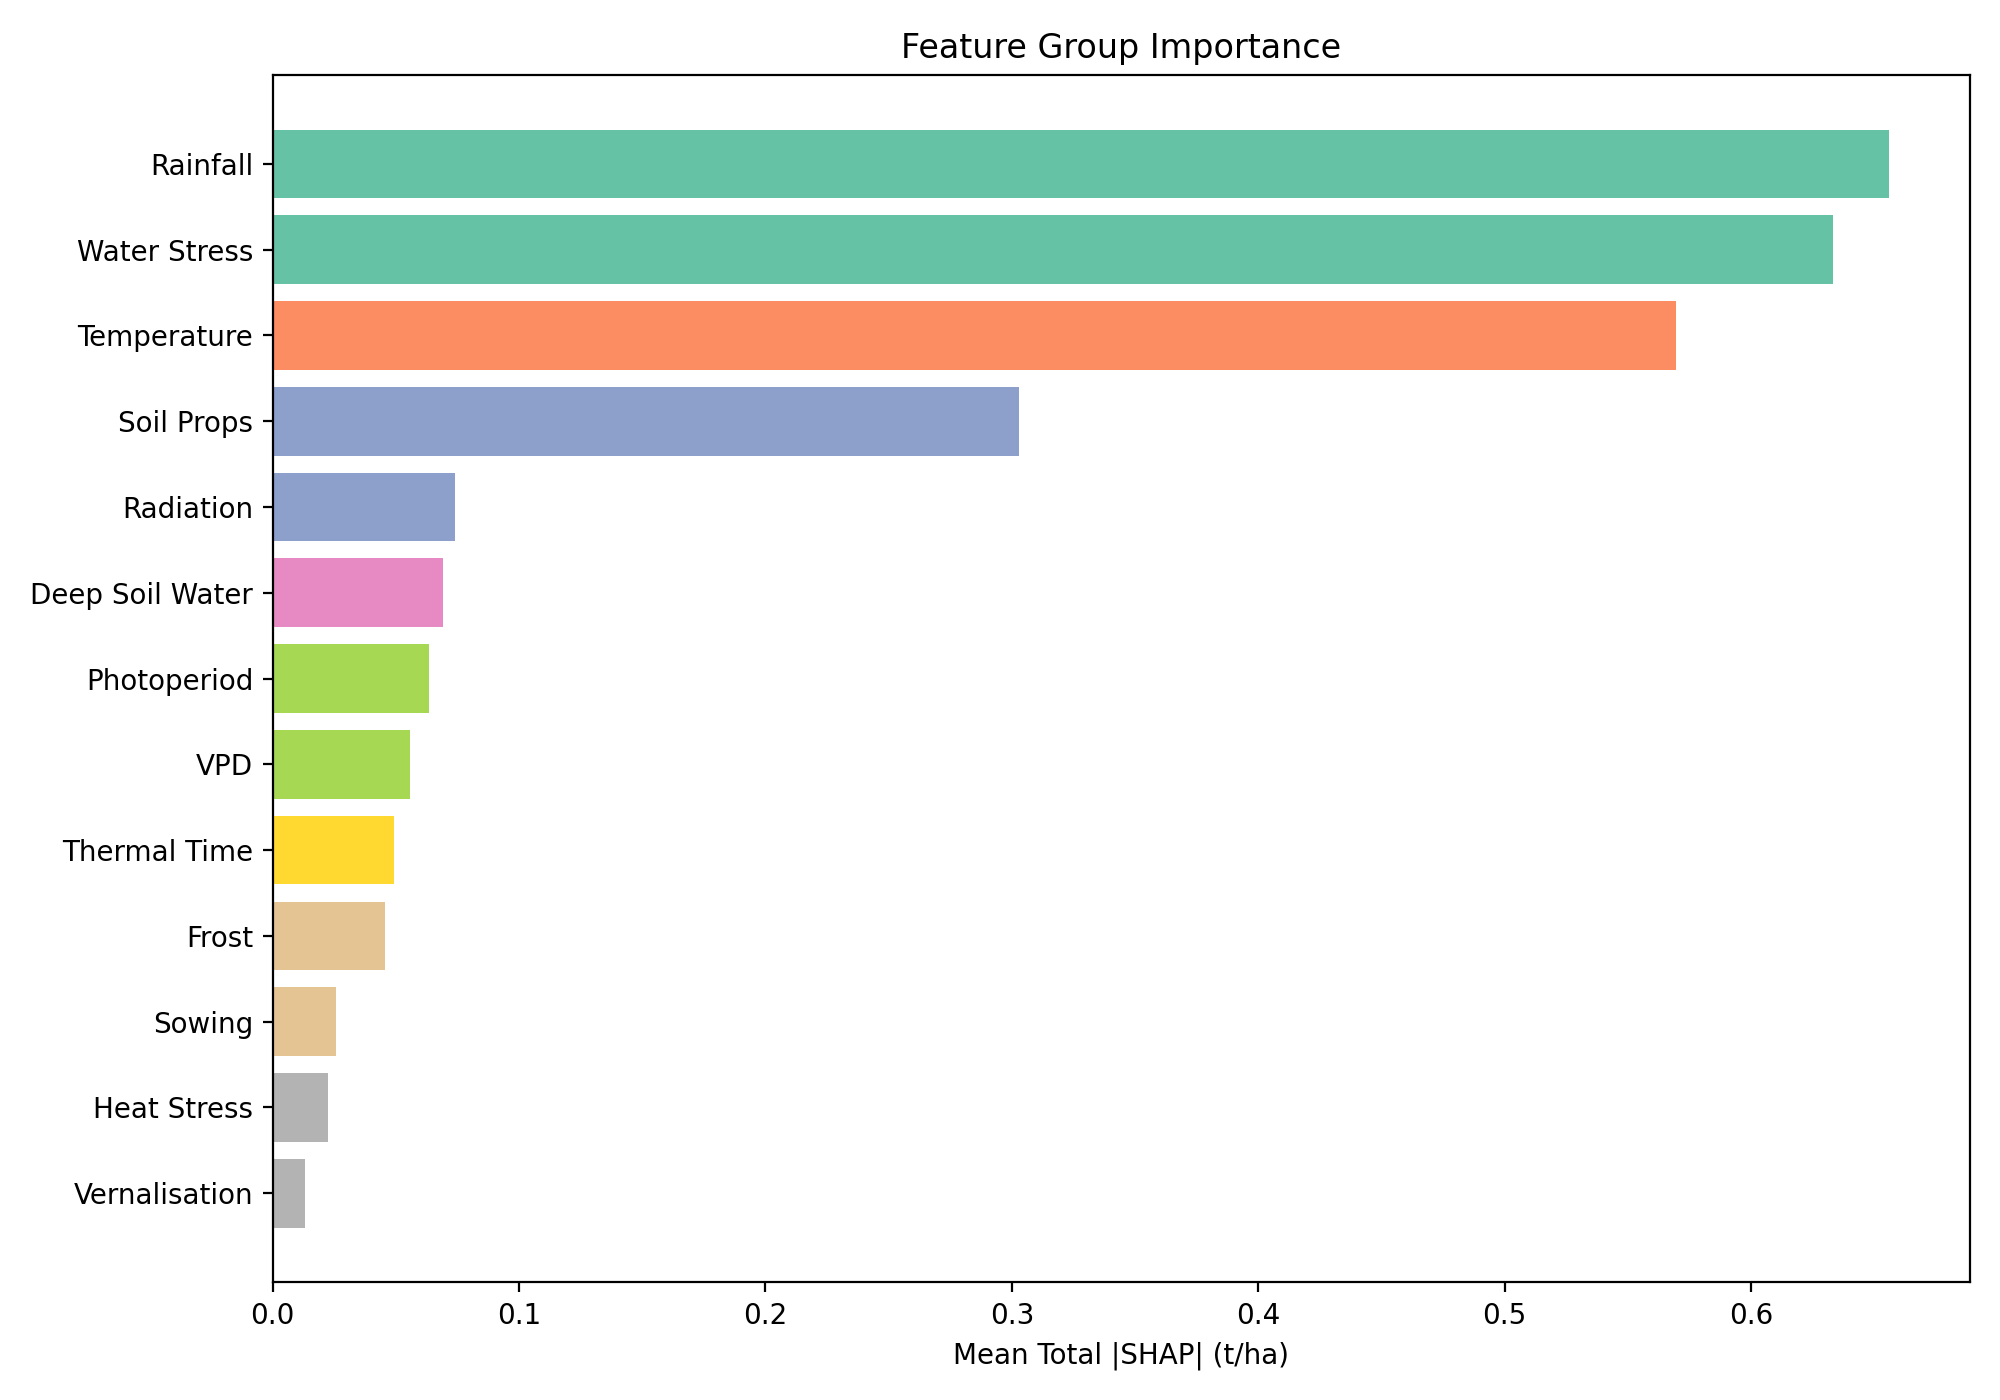

In [34]:
fig_path = Path("../outputs/ml_results_v9/figures/shap_group_importance.png")
display(Image(filename=str(fig_path)))

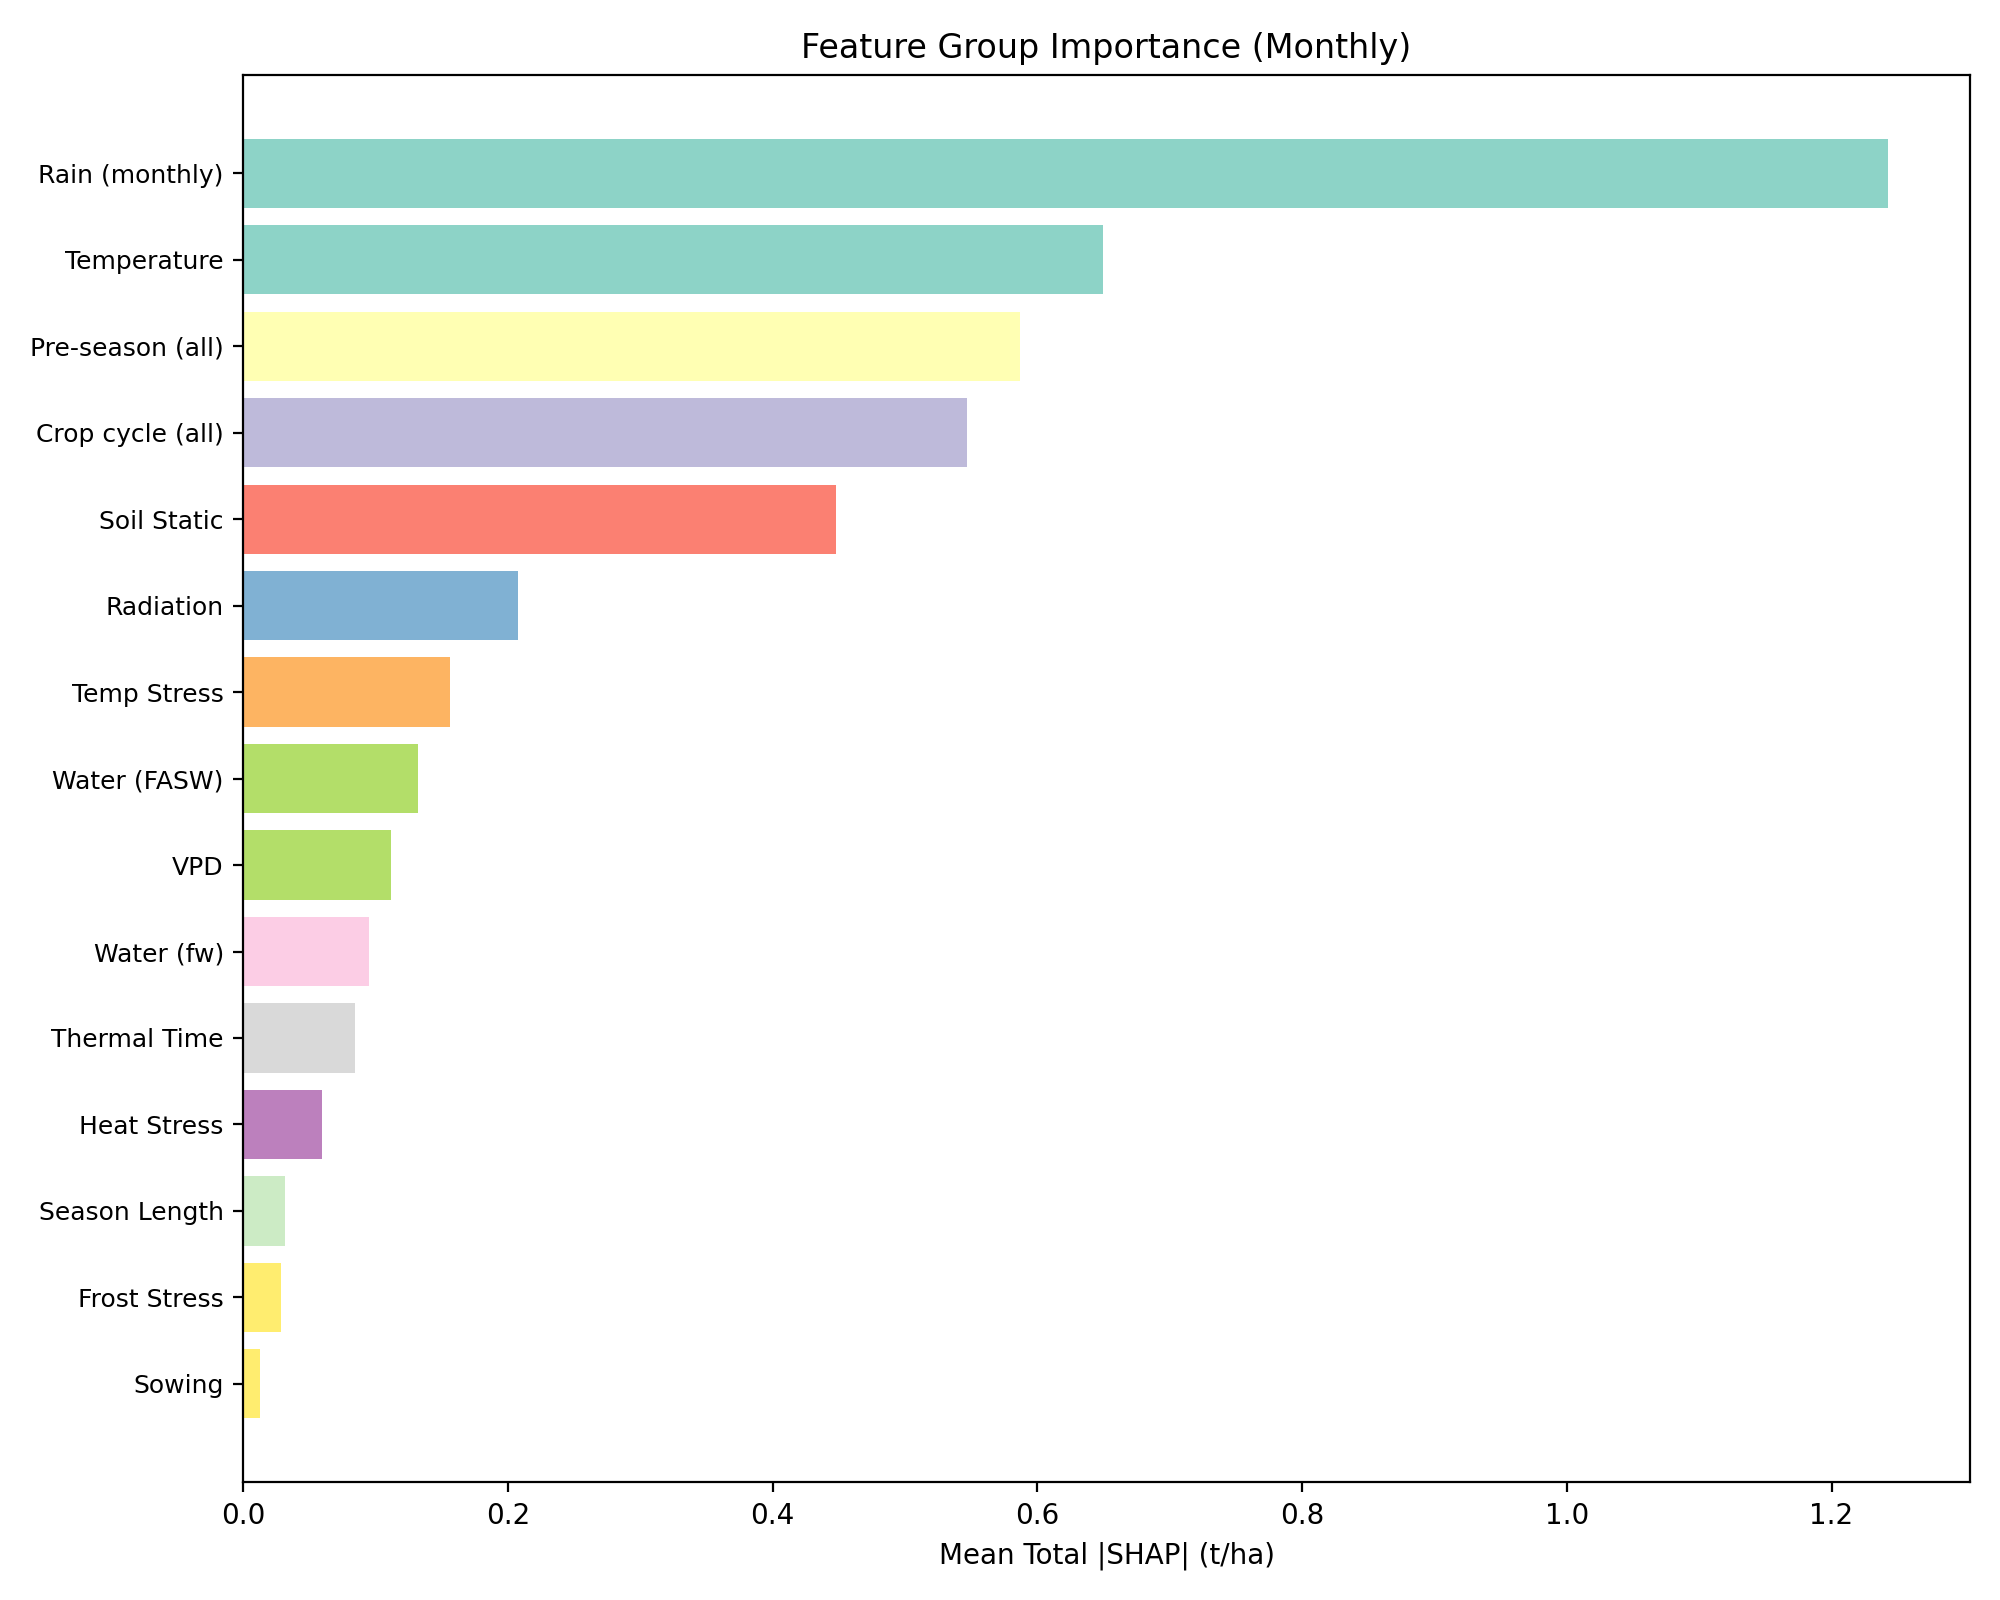

In [35]:
fig_path = Path("../outputs/ml_monthly_results/figures/shap_group_importance.png")
display(Image(filename=str(fig_path)))

### Feature groups for monthly ML


- **Rain (monthly)**: `rain_sum_*`, `rain_days_*`
- **Radiation**: `rad_*`
- **Temperature**: `tmean_*`, `tmax_max_*`, `tmin_min_*`, `diurnal_*`
- **Thermal Time**: `tt_sum_*`
- **Temp Stress**: `fT_photo_*`
- **Heat Stress**: `heat_days_*`
- **Frost Stress**: `frost_days_*`
- **VPD**: `vpd_*`
- **Water (FASW)**: `fasw_*`
- **Water (fw)**: `fw_photo_*`
- **Soil Static**: `pawc_*`, `ph_*`, `minN_*`, `profile_*`
- **Sowing**: `sowing*`
- **Season Length**: `n_days_*`

I also create two broader seasonal groups:

- **Pre-season (all)**: all features containing `_pre`
- **Crop cycle (all)**: all features containing `_crop`

### How group importance is calculated

For each feature group:

1. selecting all SHAP columns belonging to that group
2. taking the absolute SHAP values
3. summing them across all features in the group for each sample
4. averaging that summed value across samples

NOte: I have not size normalise group SHAP!!! I should do it


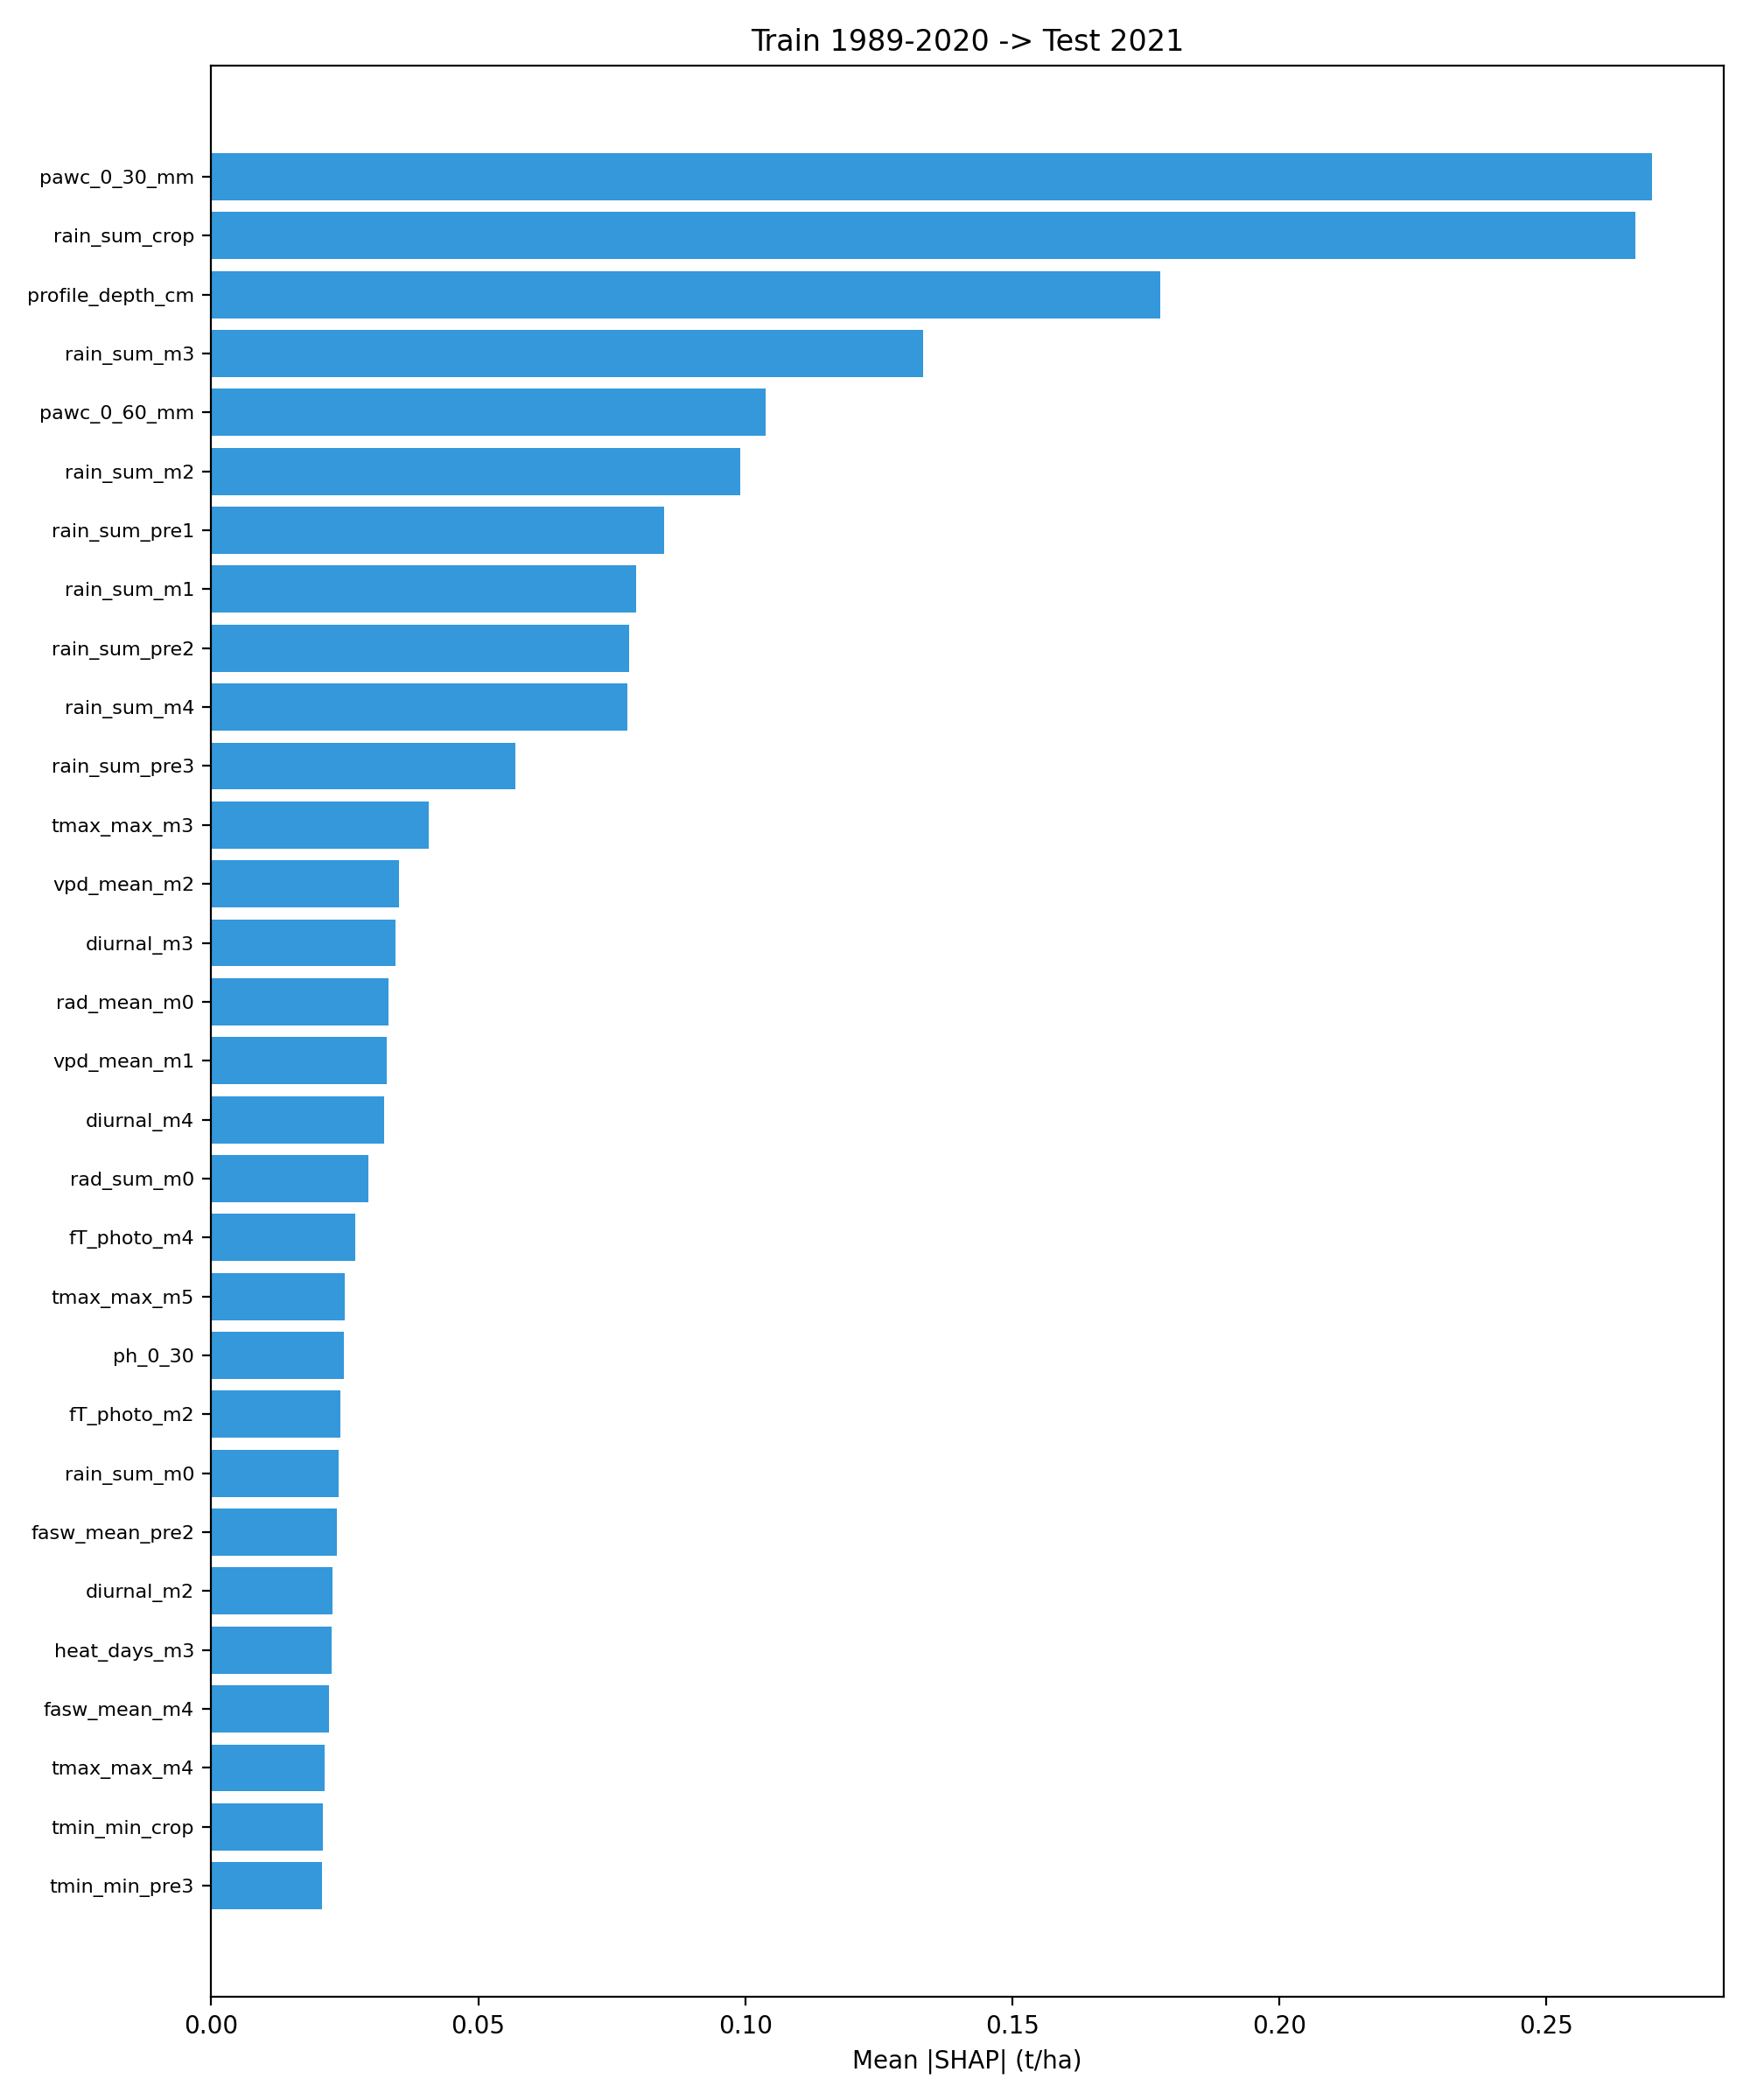

In [39]:
fig_path = Path("../outputs/ml_monthly_results/shap_per_fold/shap_bar_train_1989-2020_test_2021-2021_2021.png")
display(Image(filename=str(fig_path)))

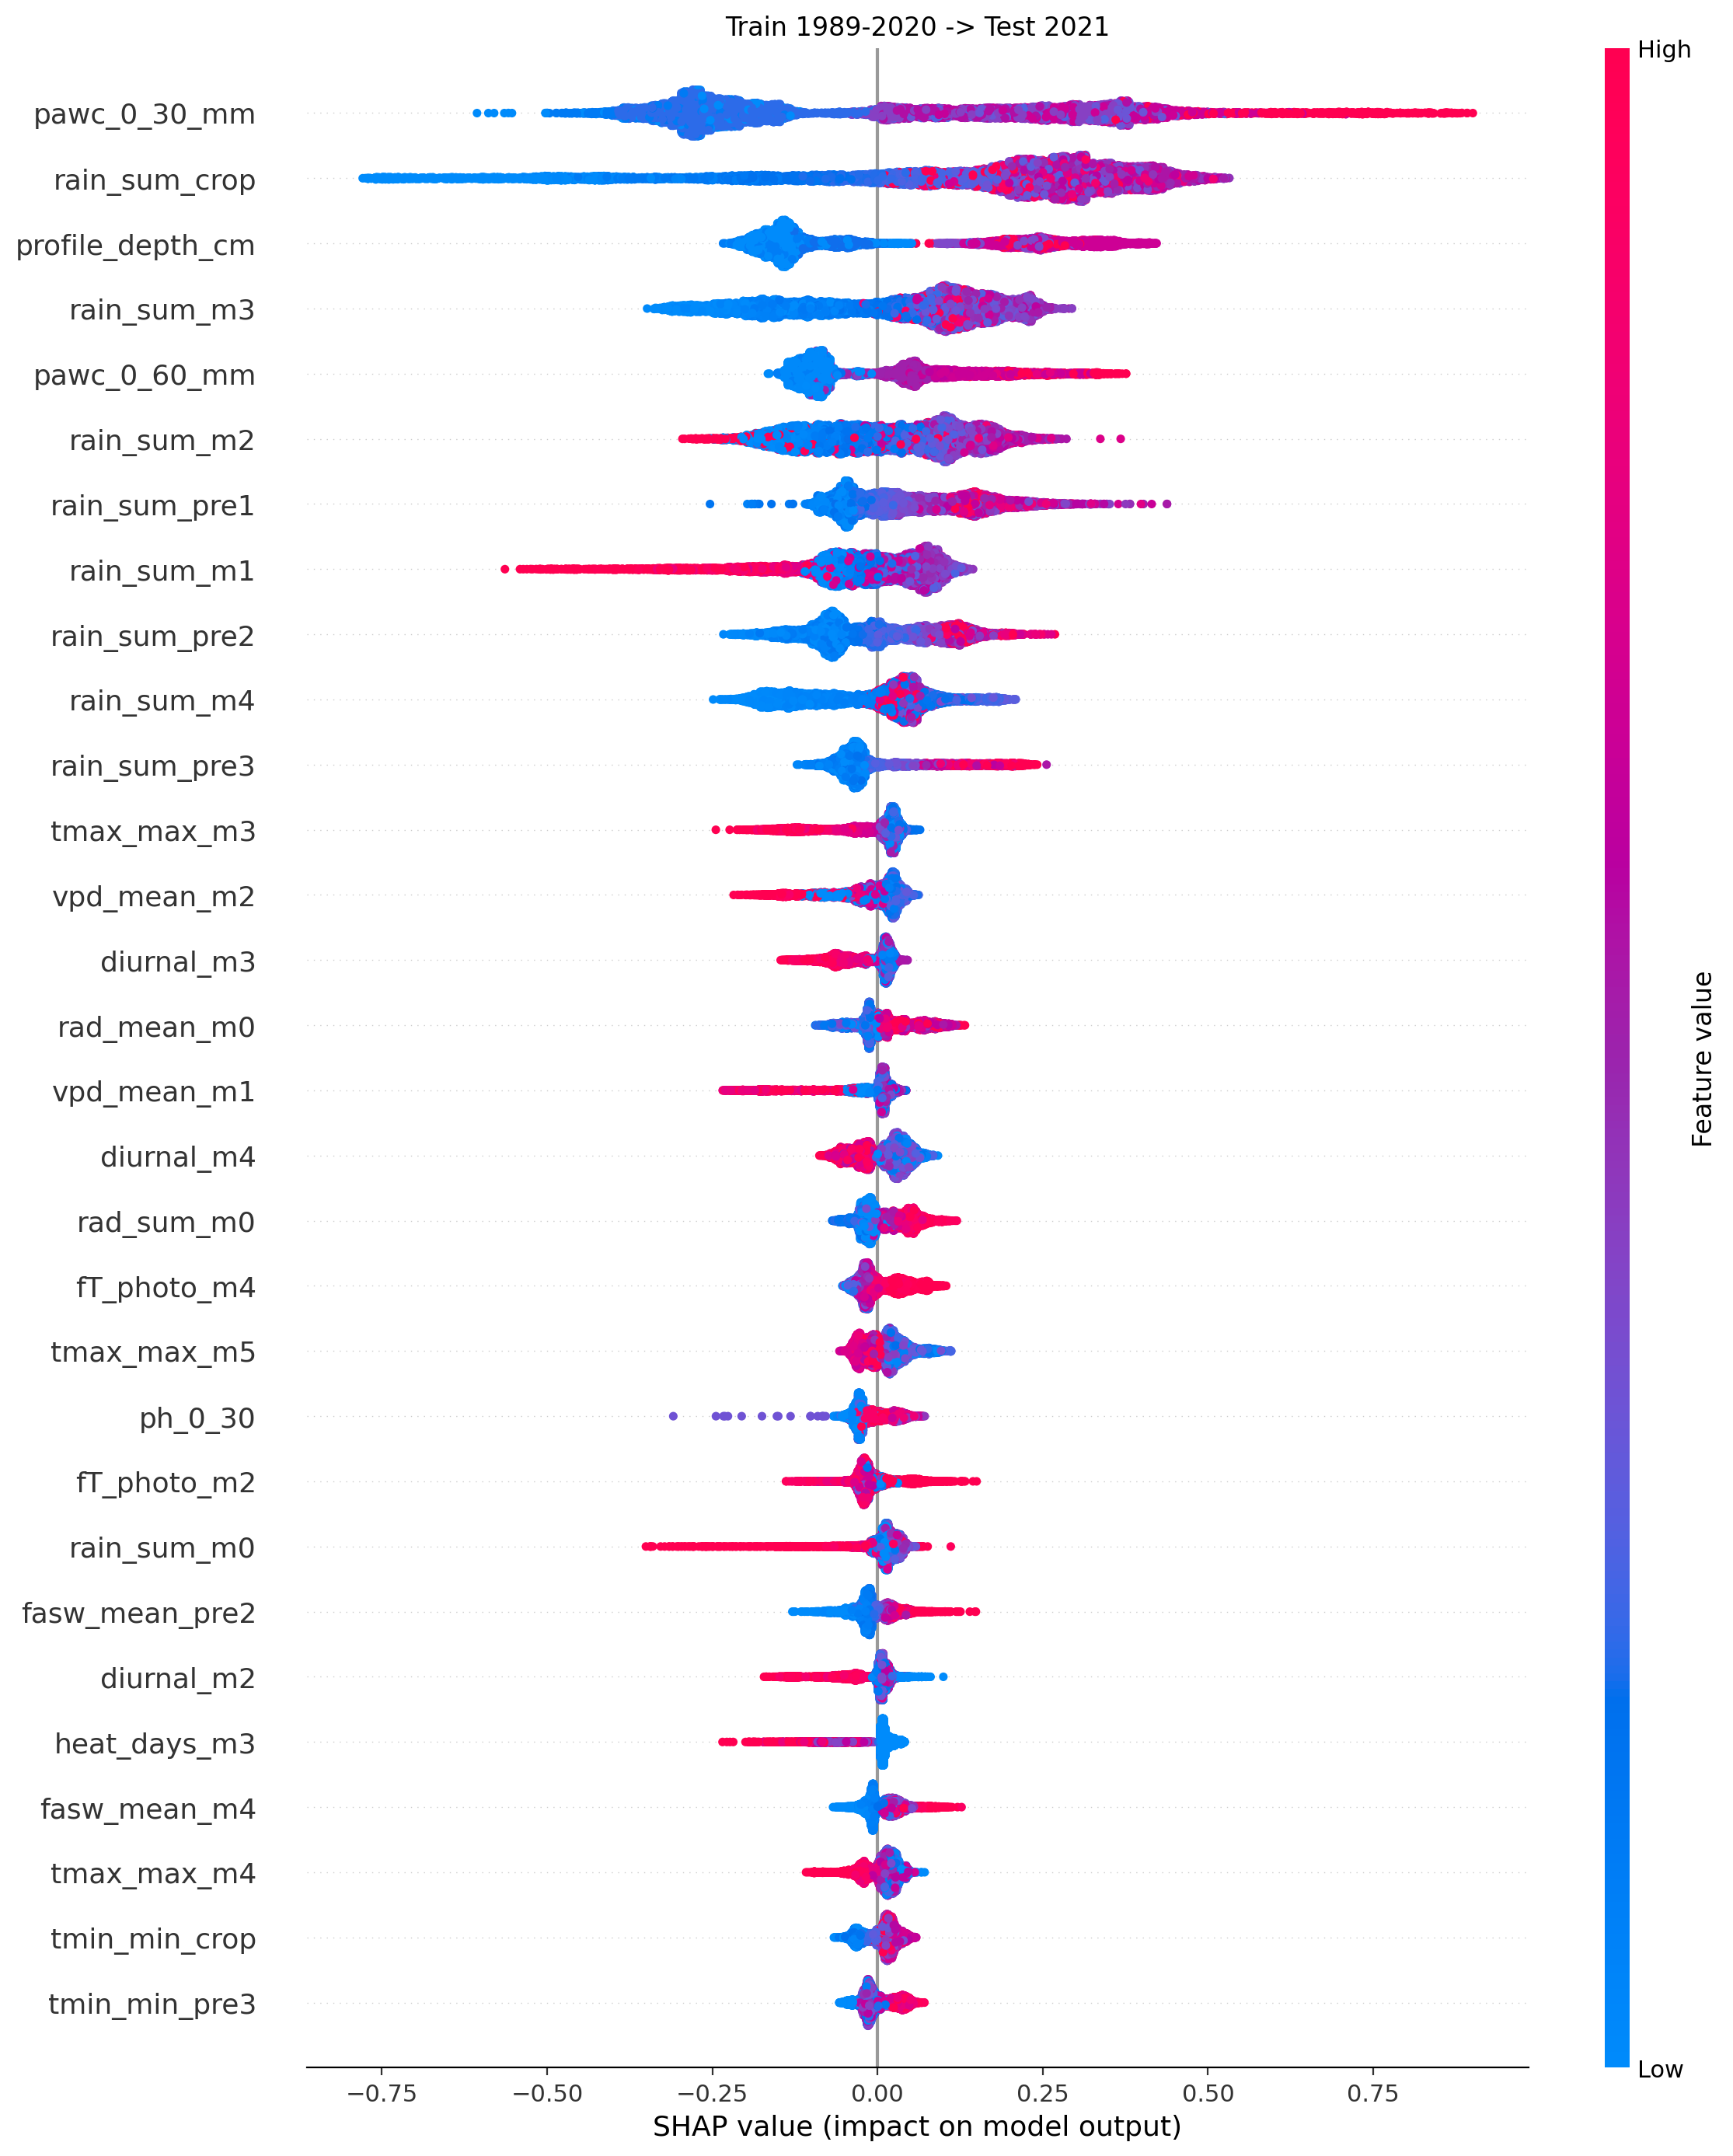

In [38]:
fig_path = Path("../outputs/ml_monthly_results/shap_per_fold/shap_beeswarm_train_1989-2020_test_2021-2021_2021.png")
display(Image(filename=str(fig_path)))


# What next
- Refining the input features: which variables used monthly or daily and which variables use crop-seson timeline.

- Each grid cell $i$, compute average yield across the training years:
$\bar{y}_i = \frac{1}{T}\sum_t y_{i,t}$

- COmpute $y'_{i,t} = y_{i,t}-\bar{y}_i$. Instead of using XGboost to predict the annual yield $y_{i,t}$, we train the model on difference and get the prediction as 
$ \hat{y}_{i,t} = \hat{y}'_{i,t}+\bar{y}_i$


- Looking at the modification of the loss function which also aims to minisimse the residual in each grid cell. 

- The current XGboost using the objective function 
\begin{equation}
L = \frac{1}{N}\sum_{i=1}^N(y_i-\hat{y}_i)^2
\end{equation}
where  $i$ is the grid cell x year

- Some possible objective function 
\begin{equation}
L =  \frac{1}{N}\sum_{i=1}^N(y_i-\hat{y}_i)^2 + \lambda \times \text{grid bias penalty}
\end{equation}

\begin{equation}
L =  Huber(y,\hat{y}) + \lambda \times \text{grid-bias penalty}
\end{equation}

Loss function capturing the drough year

\begin{equation}
L = \sum_{i} w_i(l(y_i, \hat{y}_i))
\end{equation}




